2025-01-31 01:17:36: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-01-31 01:17:36: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-01-31 01:17:36: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2025-01-31 01:17:36: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.
2025-01-31 01:17:36: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2025-01-31 01:17:36: oggm.workflow: init_glacier_directories from prepro level 5 on 1 glaciers.
2025-01-31 01:17:36: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers
2025-01-31 01:17:36: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers


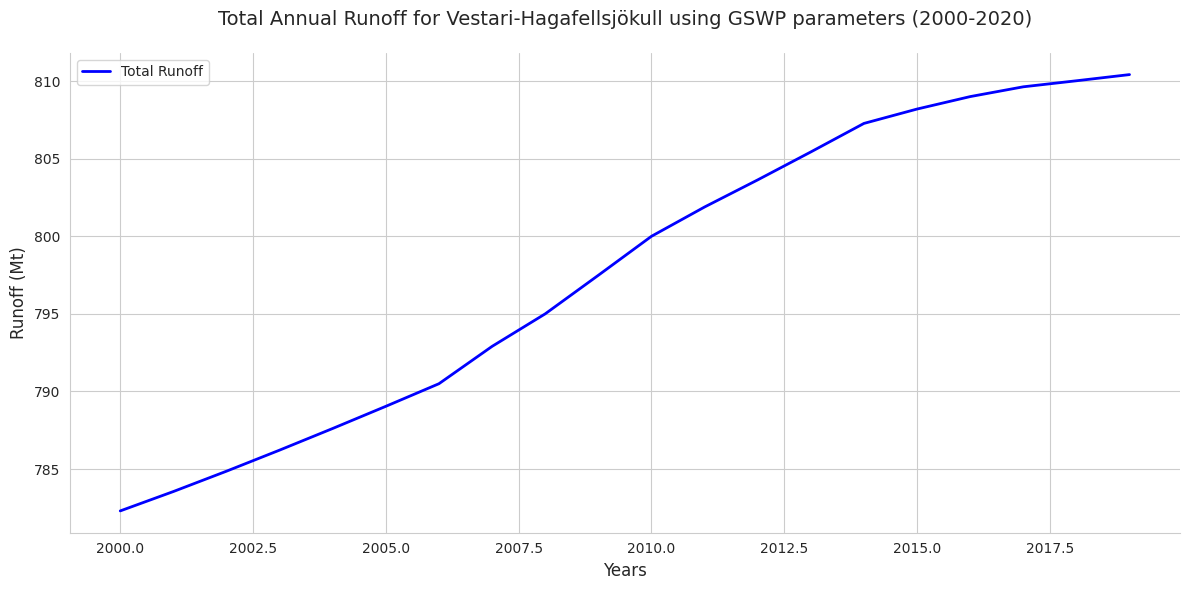

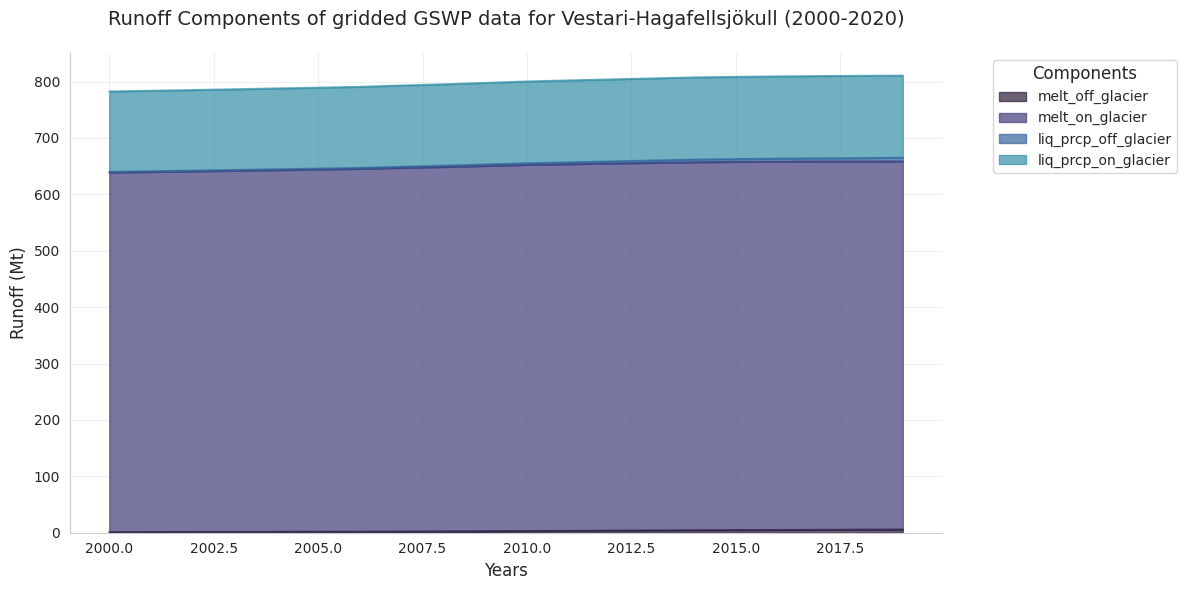


Verifying data distribution:
       melt_off_glacier  melt_on_glacier  liq_prcp_off_glacier  \
count         20.000000        20.000000             20.000000   
mean           3.065013       646.999012              3.136788   
std            1.568277         5.587531              1.774722   
min            1.020264       637.621841              1.073027   
25%            1.636667       642.044167              1.537466   
50%            2.851684       648.414276              2.695289   
75%            4.536979       652.447588              4.768090   
max            5.670721       653.116574              6.346993   

       liq_prcp_on_glacier  
count            20.000000  
mean            144.549020  
std               1.199719  
min             142.585802  
25%             143.467046  
50%             144.781959  
75%             145.709339  
max             145.889456  


In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import oggm.cfg as cfg
from oggm import utils, workflow, tasks
from oggm.shop import gcm_climate
from oggm.sandbox.edu import run_constant_climate_with_bias

# Set seaborn style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Initialize OGGM and set up the default run parameters
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir('OGGM_historical_run', reset=True)
cfg.PARAMS['min_ice_thick_for_length'] = 1
cfg.PARAMS['store_model_geometry'] = True

# Define the glacier ID
rgi_id = 'RGI60-06.00291'

# Get the pre-processed glacier directories
gdirs = workflow.init_glacier_directories([rgi_id], from_prepro_level=5, prepro_base_url=utils.DEFAULT_BASE_URL)

# Define temperature bias time series
years = np.arange(2000, 2021)
temp_bias_ts = pd.Series(1.0, index=years)

# Perform the historical run
workflow.execute_entity_task(
    tasks.run_with_hydro, gdirs,
    run_task=run_constant_climate_with_bias,
    temp_bias_ts=temp_bias_ts,
    y0=2009, halfsize=10,
    store_monthly_hydro=True,
    output_filesuffix='_historical',
    ys=2000, ye=2020
)

# Load results
with xr.open_dataset(gdirs[0].get_filepath('model_diagnostics', filesuffix='_historical')) as ds:
    ds = ds.isel(time=slice(0, -1)).load()
    historical_results = ds

# Define runoff variables
runoff_vars = ['melt_off_glacier', 'melt_on_glacier', 'liq_prcp_off_glacier', 'liq_prcp_on_glacier']

# Create figure 1: Total Runoff
plt.figure()
sel_vars = [v for v in historical_results.variables if 'month_2d' not in historical_results[v].dims]
df_annual = historical_results[sel_vars].to_dataframe()

# Convert to megatonnes and smooth
df_runoff = df_annual[runoff_vars] * 1e-9
df_runoff = df_runoff.rolling(12, center=True, min_periods=1).mean()

# Plot total runoff
total_runoff = df_runoff.sum(axis=1)
sns.lineplot(data=total_runoff, linewidth=2, color='blue', label='Total Runoff')

plt.ylabel('Runoff (Mt)', fontsize=12)
plt.xlabel('Years', fontsize=12)
plt.title(f'Total Annual Runoff for Vestari-Hagafellsjökull using GSWP parameters (2000-2020)', fontsize=14, pad=20)
plt.legend(fontsize=10)
sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

# Create figure 2: Stacked Area Plot
f, ax = plt.subplots(figsize=(12, 6))

# Create stacked area plot
df_runoff.plot.area(ax=ax, 
                    color=sns.color_palette("mako"), 
                    alpha=0.7,
                    stacked=True)

plt.xlabel('Years', fontsize=12)
plt.ylabel('Runoff (Mt)', fontsize=12)
plt.title(f'Runoff Components of gridded GSWP data for Vestari-Hagafellsjökull (2000-2020)', fontsize=14, pad=20)
 
# Improve legend
plt.legend(title='Components', 
          title_fontsize=12, 
          fontsize=10, 
          bbox_to_anchor=(1.05, 1), 
          loc='upper left')

# Final formatting
sns.despine(left=False, bottom=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the actual values to verify data
print("\nVerifying data distribution:")
print(df_runoff[runoff_vars].describe())